# STATISTICAL LEARNING THEORY 




# Statistical Learning Theory
### Section 1 — From Learning to Generalization

> **References:** Shalev-Shwartz & Ben-David – *Understanding Machine Learning* (Ch. 1–6) · Mehryar-Mohri & Afshin Rostomizadeh & Ameet Talwalker – *Foundations of Machine Learning* · Lecture notes, SMIA Sapienza

**Goal:** Build the mathematical foundations that explain *why* learning from data works — and when it fails. We move from the informal idea of "learning a function" to precise notions of risk, empirical minimization, and the conditions under which a learner can generalize.

---

## Table of Contents
1. [Learning Deterministic Functions](#1-learning-deterministic-functions)
2. [Expected Risk, Input and Output Spaces](#2-expected-risk-input-and-output-spaces)
3. [Loss Functions — Hinge Loss vs Log Loss](#3-loss-functions)
4. [Empirical Risk Minimization (ERM)](#4-empirical-risk-minimization-erm)
5. [Bayes Optimal Classifier](#5-bayes-optimal-classifier)
6. [Excess Risk, Consistency & Universality](#6-excess-risk-consistency--universality)
7. [No Free Lunch Theorem](#7-no-free-lunch-theorem)
8. [Estimation & Approximation Error — Bias-Variance Trade-off](#8-estimation--approximation-error--bias-variance-trade-off)

---
## Introduction

Statistical learning theory is a framework for understanding and analyzing the process of learning from data. It provides the theoretical foundation for machine learning algorithms and helps us understand the trade-offs between model complexity, training data, and generalization performance.

Despite being associated with computer science, statistical learning theory is fundamentally mathematics — probability theory, functional analysis, and combinatorics all play central roles. The core question it asks is deceptively simple:

> *Given a finite sample of observations, under what conditions can we learn something that generalizes to unseen data?*

This is not obvious. A model can memorize training data perfectly and fail completely on new inputs. Understanding the gap between what we observe and what we want to predict is the central problem of the field.

---
# 1. Learning Deterministic Functions

The simplest learning scenario: assume there exists an unknown **target function**
$$f^*: \mathcal{X} \to \mathcal{Y}$$
that maps inputs to outputs **deterministically** — no noise, no randomness. The learner observes a training set
$$S = \{(x_1, y_1), \dots, (x_m, y_m)\}, \quad y_i = f^*(x_i)$$
and must return a hypothesis $h: \mathcal{X} \to \mathcal{Y}$ that approximates $f^*$.

### The core challenge

Even in this noise-free setting, learning is non-trivial. The training set $S$ only covers a finite subset of $\mathcal{X}$. For any unseen point $x \notin \{x_1, \dots, x_m\}$, the learner must **extrapolate** — and there are infinitely many functions consistent with $S$ that disagree on the rest of $\mathcal{X}$.

This is why we need **inductive bias**: constraints on the hypothesis class $\mathcal{H}$ that guide the learner toward generalizable solutions.

| Concept | Symbol | Meaning |
|---|---|---|
| Input space | $\mathcal{X}$ | Domain of all possible inputs |
| Output space | $\mathcal{Y}$ | Set of possible labels/values |
| Target function | $f^*$ | The true (unknown) mapping |
| Hypothesis | $h \in \mathcal{H}$ | The learner's guess |
| Training set | $S$ | Finite sample of $(x, f^*(x))$ pairs |

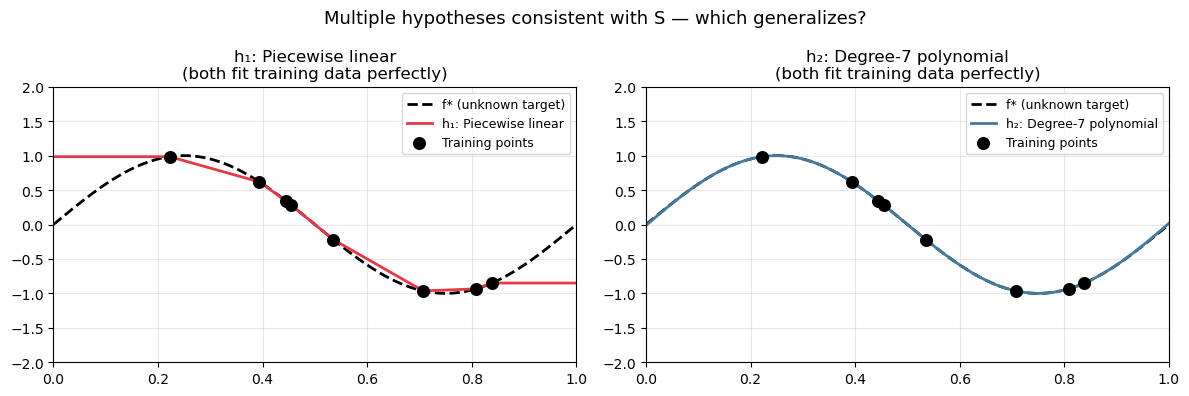

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# True (unknown) target function
f_star = lambda x: np.sin(2 * np.pi * x)

# Training set: 8 noise-free observations
x_train = np.sort(np.random.choice(np.linspace(0, 1, 100), 8, replace=False))
y_train = f_star(x_train)

x_all = np.linspace(0, 1, 300)

# Two hypotheses consistent with the training data
h1 = np.interp(x_all, x_train, y_train)  # piecewise linear
h2 = np.polyval(np.polyfit(x_train, y_train, deg=7), x_all)  # high-degree poly

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, h, label, color in zip(
    axes,
    [h1, h2],
    ['h₁: Piecewise linear', 'h₂: Degree-7 polynomial'],
    ['#E63946', '#457B9D']
):
    ax.plot(x_all, f_star(x_all), 'k--', lw=2, label='f* (unknown target)')
    ax.plot(x_all, h, color=color, lw=2, label=label)
    ax.scatter(x_train, y_train, s=70, zorder=5, color='black', label='Training points')
    ax.set_xlim(0, 1); ax.set_ylim(-2, 2)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
    ax.set_title(f'{label}\n(both fit training data perfectly)')

plt.suptitle('Multiple hypotheses consistent with S — which generalizes?', fontsize=13)
plt.tight_layout()
plt.show()

---
# 2. Expected Risk, Input and Output Spaces

In the realistic (statistical) setting, data is generated by an unknown **joint distribution** $\mathcal{D}$ over $\mathcal{X} \times \mathcal{Y}$. Labels may be noisy — the same input $x$ might produce different outputs in different draws.

## 2.1 Setup

- **Input space** $\mathcal{X} \subseteq \mathbb{R}^d$: the feature space (e.g., pixel values, word embeddings)
- **Output space** $\mathcal{Y}$: 
  - Binary classification: $\mathcal{Y} = \{0, 1\}$ or $\{-1, +1\}$
  - Multiclass: $\mathcal{Y} = \{1, \dots, K\}$
  - Regression: $\mathcal{Y} = \mathbb{R}$
- **Data generating distribution**: $(x, y) \sim \mathcal{D}$
- **Training set**: $S = \{(x_i, y_i)\}_{i=1}^m \overset{\text{i.i.d.}}{\sim} \mathcal{D}$

## 2.2 Expected Risk (True Risk)

The **expected risk** (or **true risk**) of a hypothesis $h: \mathcal{X} \to \mathcal{Y}$ under distribution $\mathcal{D}$ is:

$$
\boxed{R(h) = \mathbb{E}_{(x,y) \sim \mathcal{D}}\left[\ell(h(x), y)\right]}
$$

where $\ell: \mathcal{Y} \times \mathcal{Y} \to \mathbb{R}_{\geq 0}$ is a **loss function** measuring how wrong $h(x)$ is compared to $y$.

This is what we *actually* want to minimize — but we cannot compute it directly because $\mathcal{D}$ is unknown.

> **The fundamental problem of learning:** We want to minimize $R(h)$, but we only have access to a finite sample $S$ from $\mathcal{D}$.

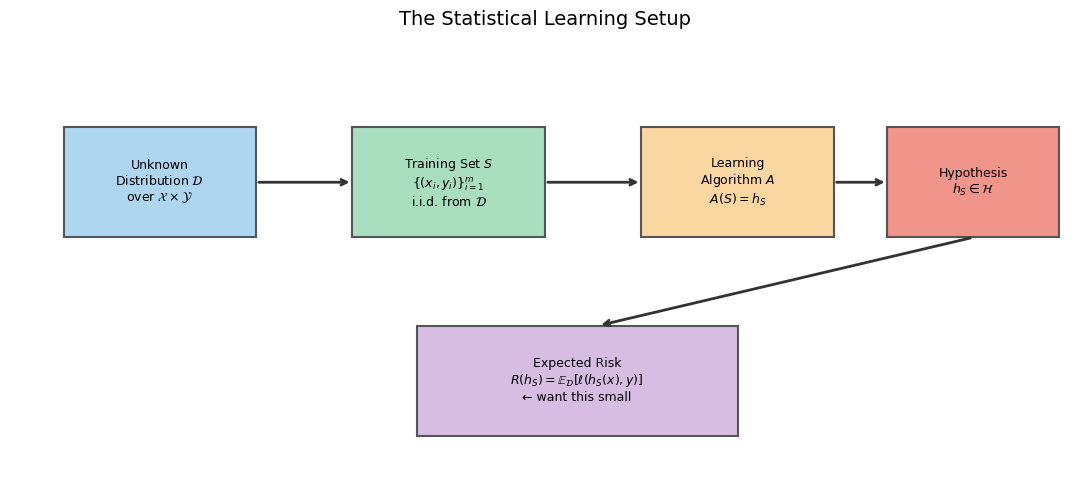

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

# Visualize the statistical learning setup
fig, ax = plt.subplots(figsize=(11, 5))
ax.axis('off')

boxes = [
    (0.05, 0.55, 0.18, 0.25, '#AED6F1', 'Unknown\nDistribution $\\mathcal{D}$\nover $\\mathcal{X} \\times \\mathcal{Y}$'),
    (0.32, 0.55, 0.18, 0.25, '#A9DFBF', 'Training Set $S$\n$\\{(x_i, y_i)\\}_{i=1}^m$\ni.i.d. from $\\mathcal{D}$'),
    (0.59, 0.55, 0.18, 0.25, '#FAD7A0', 'Learning\nAlgorithm $A$\n$A(S) = h_S$'),
    (0.82, 0.55, 0.16, 0.25, '#F1948A', 'Hypothesis\n$h_S \\in \\mathcal{H}$'),
    (0.38, 0.10, 0.30, 0.25, '#D7BDE2', 'Expected Risk\n$R(h_S) = \\mathbb{E}_{\\mathcal{D}}[\\ell(h_S(x), y)]$\n← want this small'),
]

for (x, y, w, h, color, text) in boxes:
    rect = plt.Rectangle((x, y), w, h, linewidth=1.5,
                          edgecolor='#555', facecolor=color, transform=ax.transAxes, zorder=2)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, text, ha='center', va='center',
            fontsize=9, transform=ax.transAxes, zorder=3)

# Arrows
arrows = [(0.23, 0.675, 0.32, 0.675), (0.50, 0.675, 0.59, 0.675), (0.77, 0.675, 0.82, 0.675),
          (0.90, 0.55, 0.55, 0.35)]
for (x1,y1,x2,y2) in arrows:
    ax.annotate('', xy=(x2,y2), xytext=(x1,y1),
                xycoords='axes fraction', textcoords='axes fraction',
                arrowprops=dict(arrowstyle='->', color='#333', lw=2))

ax.set_title('The Statistical Learning Setup', fontsize=14, pad=10)
plt.tight_layout()
plt.show()

---
# 3. Loss Functions

The **loss function** $\ell(\hat{y}, y)$ quantifies the cost of predicting $\hat{y}$ when the true label is $y$. The choice of loss function encodes our assumptions about what kinds of errors matter.

## 3.1 0-1 Loss (Classification)

The most natural loss for classification:
$$\ell_{0-1}(h(x), y) = \mathbf{1}[h(x) \neq y]$$

Simple to interpret, but **not differentiable** — cannot be optimized with gradient methods directly.

## 3.2 Hinge Loss (SVM)

Used in Support Vector Machines. For $y \in \{-1, +1\}$ and a real-valued score $\hat{y} = w^\top x$:

$$\ell_{\text{hinge}}(\hat{y}, y) = \max(0,\; 1 - y \cdot \hat{y})$$

- Zero when the prediction is correct **and** confident (margin $\geq 1$)
- Linear penalty when the margin is violated
- **Convex** and differentiable almost everywhere → gradient methods work
- Produces **sparse solutions**: many training points contribute zero loss (support vectors are the exception)

## 3.3 Log Loss / Binary Cross-Entropy (Logistic Regression)

Used in logistic regression and neural networks. For $y \in \{0, 1\}$ and predicted probability $\hat{p} = \sigma(w^\top x)$:

$$\ell_{\text{log}}(\hat{p}, y) = -y \log(\hat{p}) - (1-y)\log(1 - \hat{p})$$

Equivalently, for $y \in \{-1, +1\}$ and score $\hat{y}$:
$$\ell_{\text{log}}(\hat{y}, y) = \log\left(1 + e^{-y\hat{y}}\right)$$

- **Always positive** — never truly zero, even for correct predictions
- **Smooth and strictly convex** — gradient is always defined
- Derived from maximum likelihood under a Bernoulli model

## 3.4 Hinge vs Log Loss — Comparison

| Property | Hinge Loss | Log Loss |
|---|---|---|
| Zero loss region | Yes (when $y\hat{y} \geq 1$) | No (always $> 0$) |
| Gradient | Piecewise constant | Smooth everywhere |
| Sparsity | Sparse (support vectors) | Dense updates |
| Probabilistic output | No | Yes (calibrated probabilities) |
| Algorithm | SVM | Logistic Regression, Neural Nets |
| Sensitivity to outliers | Linear (bounded sensitivity) | Exponential decay (robust to far outliers) |

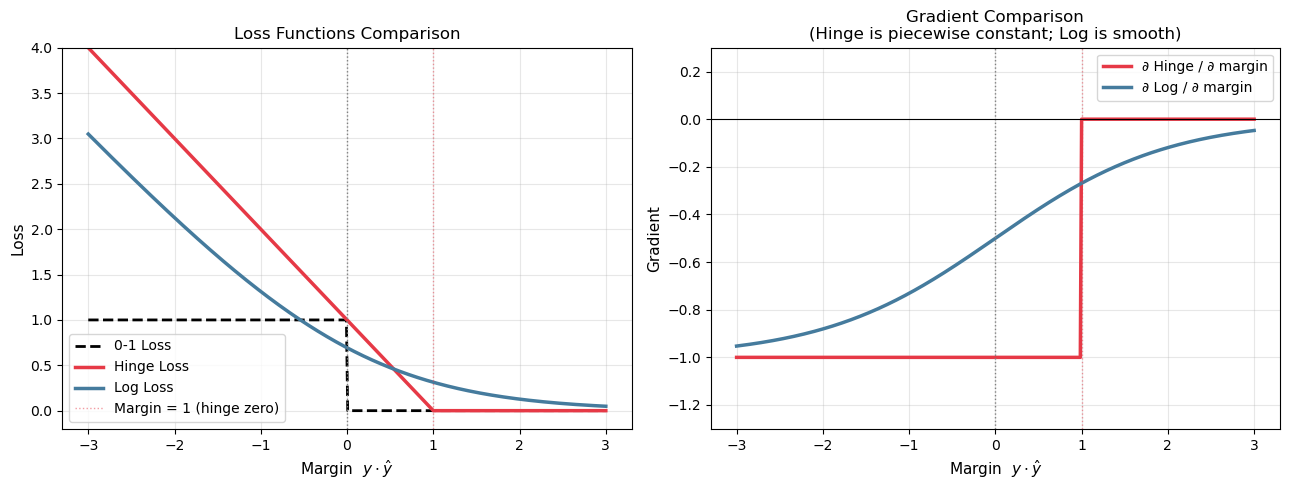

=== Loss values at key margins ===
margin=-2.0  |  hinge=3.0000  |  log=2.1269
margin=-1.0  |  hinge=2.0000  |  log=1.3133
margin= 0.0  |  hinge=1.0000  |  log=0.6931
margin= 0.5  |  hinge=0.5000  |  log=0.4741
margin= 1.0  |  hinge=0.0000  |  log=0.3133
margin= 2.0  |  hinge=0.0000  |  log=0.1269


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# margin = y * y_hat  (positive = correct side)
margin = np.linspace(-3, 3, 400)

loss_01    = (margin < 0).astype(float)                     # 0-1 loss
loss_hinge = np.maximum(0, 1 - margin)                      # hinge
loss_log   = np.log(1 + np.exp(-margin))                    # log loss

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: all three losses ---
ax = axes[0]
ax.plot(margin, loss_01,    'k--',  lw=2,   label='0-1 Loss')
ax.plot(margin, loss_hinge, '#E63946', lw=2.5, label='Hinge Loss')
ax.plot(margin, loss_log,   '#457B9D', lw=2.5, label='Log Loss')
ax.axvline(0, color='gray', lw=1, linestyle=':')
ax.axvline(1, color='#E63946', lw=1, linestyle=':', alpha=0.5, label='Margin = 1 (hinge zero)')
ax.set_xlabel('Margin  $y \\cdot \\hat{y}$', fontsize=11)
ax.set_ylabel('Loss', fontsize=11)
ax.set_ylim(-0.2, 4)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_title('Loss Functions Comparison', fontsize=12)

# --- Right: gradient comparison ---
ax2 = axes[1]

# Hinge gradient: -1 if margin < 1 else 0
grad_hinge = np.where(margin < 1, -1.0, 0.0)
# Log loss gradient: -sigmoid(-margin)
grad_log   = -1 / (1 + np.exp(margin))

ax2.plot(margin, grad_hinge, '#E63946', lw=2.5, label='∂ Hinge / ∂ margin')
ax2.plot(margin, grad_log,   '#457B9D', lw=2.5, label='∂ Log / ∂ margin')
ax2.axvline(0, color='gray', lw=1, linestyle=':')
ax2.axvline(1, color='#E63946', lw=1, linestyle=':', alpha=0.5)
ax2.axhline(0, color='black', lw=0.8)
ax2.set_xlabel('Margin  $y \\cdot \\hat{y}$', fontsize=11)
ax2.set_ylabel('Gradient', fontsize=11)
ax2.set_ylim(-1.3, 0.3)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_title('Gradient Comparison\n(Hinge is piecewise constant; Log is smooth)', fontsize=12)

plt.tight_layout()
plt.show()

# Print key values
print("=== Loss values at key margins ===")
for m in [-2, -1, 0, 0.5, 1, 2]:
    h = max(0, 1-m)
    l = np.log(1 + np.exp(-m))
    print(f"margin={m:4.1f}  |  hinge={h:.4f}  |  log={l:.4f}")

---
# 4. Empirical Risk Minimization (ERM)

Since $R(h) = \mathbb{E}_{\mathcal{D}}[\ell(h(x),y)]$ is inaccessible (we don't know $\mathcal{D}$), we approximate it using the training set $S$.

## 4.1 Empirical Risk

The **empirical risk** is the average loss on the training set:

$$
\boxed{\hat{R}_S(h) = \frac{1}{m} \sum_{i=1}^{m} \ell(h(x_i), y_i)}
$$

By the **Law of Large Numbers**, $\hat{R}_S(h) \xrightarrow{m \to \infty} R(h)$ for any fixed $h$. This justifies using $\hat{R}_S$ as a proxy for $R$.

## 4.2 The ERM Principle

**Empirical Risk Minimization** chooses the hypothesis that minimizes the empirical risk over a hypothesis class $\mathcal{H}$:

$$
h_S = \underset{h \in \mathcal{H}}{\arg\min}\; \hat{R}_S(h)
$$

## 4.3 The Risk of ERM: Overfitting

ERM can fail catastrophically if $\mathcal{H}$ is too expressive. Consider a hypothesis class that can memorize any finite set of points — it will always achieve $\hat{R}_S = 0$ but may have $R(h_S) \approx 1$.

This is **overfitting**: the model fits the training noise instead of the underlying pattern.

The solution is to **restrict $\mathcal{H}$** to a class of limited complexity — trading off expressive power for generalization. This is the central tension of statistical learning theory.

| | Empirical Risk $\hat{R}_S(h)$ | True Risk $R(h)$ |
|---|---|---|
| **Underfitting** (small $\mathcal{H}$) | High | High |
| **Good fit** | Low | Low |
| **Overfitting** (large $\mathcal{H}$) | Very low / 0 | High |

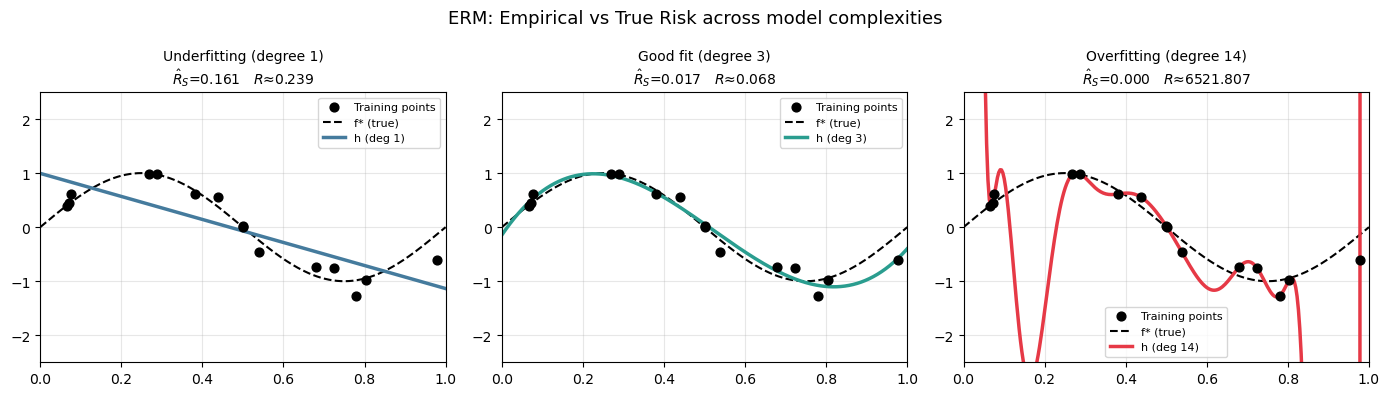

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import make_pipeline

np.random.seed(7)

f_star = lambda x: np.sin(2 * np.pi * x)
x_train = np.sort(np.random.uniform(0, 1, 15))
y_train = f_star(x_train) + np.random.normal(0, 0.2, size=15)
x_test  = np.sort(np.random.uniform(0, 1, 200))
y_test  = f_star(x_test) + np.random.normal(0, 0.2, size=200)
x_plot  = np.linspace(0, 1, 300)

degrees = [1, 3, 14]
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
titles = ['Underfitting (degree 1)', 'Good fit (degree 3)', 'Overfitting (degree 14)']
colors = ['#457B9D', '#2A9D8F', '#E63946']

for ax, deg, title, color in zip(axes, degrees, titles, colors):
    model = make_pipeline(PolynomialFeatures(deg), LinearRegression())
    model.fit(x_train.reshape(-1,1), y_train)

    train_loss = mean_squared_error(y_train, model.predict(x_train.reshape(-1,1)))
    test_loss  = mean_squared_error(y_test,  model.predict(x_test.reshape(-1,1)))

    ax.scatter(x_train, y_train, s=40, color='black', zorder=5, label='Training points')
    ax.plot(x_plot, f_star(x_plot), 'k--', lw=1.5, label='f* (true)')
    ax.plot(x_plot, model.predict(x_plot.reshape(-1,1)), color=color, lw=2.5, label=f'h (deg {deg})')
    ax.set_xlim(0, 1); ax.set_ylim(-2.5, 2.5)
    ax.grid(True, alpha=0.3)
    ax.set_title(f'{title}\n$\\hat{{R}}_S$={train_loss:.3f}   $R$≈{test_loss:.3f}', fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle('ERM: Empirical vs True Risk across model complexities', fontsize=13)
plt.tight_layout()
plt.show()

## 4.4 Beyond ERM: Structural Risk Minimization via Regularization

Pure Empirical Risk Minimization (ERM) is highly prone to overfitting (high variance) when the hypothesis class $\mathcal{H}$ is overly expressive. To balance the Bias-Variance trade-off, we transition to Regularized Loss Minimization by adding a penalty term $\Omega(\mathbf{w})$ scaled by a hyperparameter $\lambda > 0$:

$$h_{\mathbf{w}} = \arg\min_{\mathbf{w}} \left( \hat{R}_S(h_{\mathbf{w}}) + \lambda \Omega(\mathbf{w}) \right)$$

The choice of the norm in $\Omega(\mathbf{w})$ dictates the inductive bias and the geometric behavior of the weight space optimization.

### $L_2$ Regularization (Ridge) — Isotropic Shrinkage
When setting $\Omega(\mathbf{w}) = \|\mathbf{w}\|_2^2$, we penalize the squared Euclidean norm of the weights. 

* **Mathematical Form:** $\Omega(\mathbf{w}) = \sum_{i=1}^d w_i^2$
* **Geometric Intuition:** The constraint region forms a smooth hypersphere (a circle in $\mathbb{R}^2$). Because the sphere is **isotropic**, the penalty applies uniformly across all coordinate directions without favoring any specific feature. 
* **Effect:** It shrinks all weights smoothly towards zero, preventing any single feature from dominating, but it rarely sets weights exactly to zero due to the lack of singularities (corners) on the axes.

### $L_1$ Regularization (Lasso) — Sparsity Promotion
When setting $\Omega(\mathbf{w}) = \|\mathbf{w}\|_1$, we penalize the sum of absolute values.

* **Mathematical Form:** $\Omega(\mathbf{w}) = \sum_{i=1}^d |w_i|$
* **Geometric Intuition:** The constraint region forms a cross-polytope (a diamond/rhombus in $\mathbb{R}^2$). 
* **Effect:** The contours of the empirical loss are mathematically more likely to intersect the penalty region at its sharp vertices (corners) lying directly on the coordinate axes. This forces non-essential weights to become **exactly zero**, effectively performing embedded feature selection and yielding a **sparse model**.

---
# 5. Bayes Optimal Classifier

What is the best possible classifier, if we knew $\mathcal{D}$ exactly?

## 5.1 Definition

For binary classification with the 0-1 loss, the **Bayes optimal classifier** is:

$$
\boxed{h^*(x) = \underset{y \in \mathcal{Y}}{\arg\max}\; P(Y = y \mid X = x)}
$$

It simply predicts the most likely label given $x$ — the **maximum a posteriori (MAP)** decision.

## 5.2 Bayes Risk

The **Bayes risk** $R^*$ is the expected risk of the Bayes optimal classifier:

$$
R^* = R(h^*) = \mathbb{E}_x\left[\min\left(P(Y=1|x),\; P(Y=0|x)\right)\right]
$$

This is the **irreducible error** — the minimum risk achievable by any classifier, even with unlimited data. It is non-zero when the data generating process is inherently noisy (two inputs can have identical features but different labels).

## 5.3 Key Insight

- $R^* = 0$: the problem is noiseless — perfect classification is theoretically possible
- $R^* > 0$: there is irreducible noise — even the best classifier makes mistakes
- The Bayes classifier is the **gold standard** against which all learners are compared

> **Important:** The Bayes classifier is a theoretical benchmark, not a practical algorithm — it requires knowing $\mathcal{D}$, which we never do.

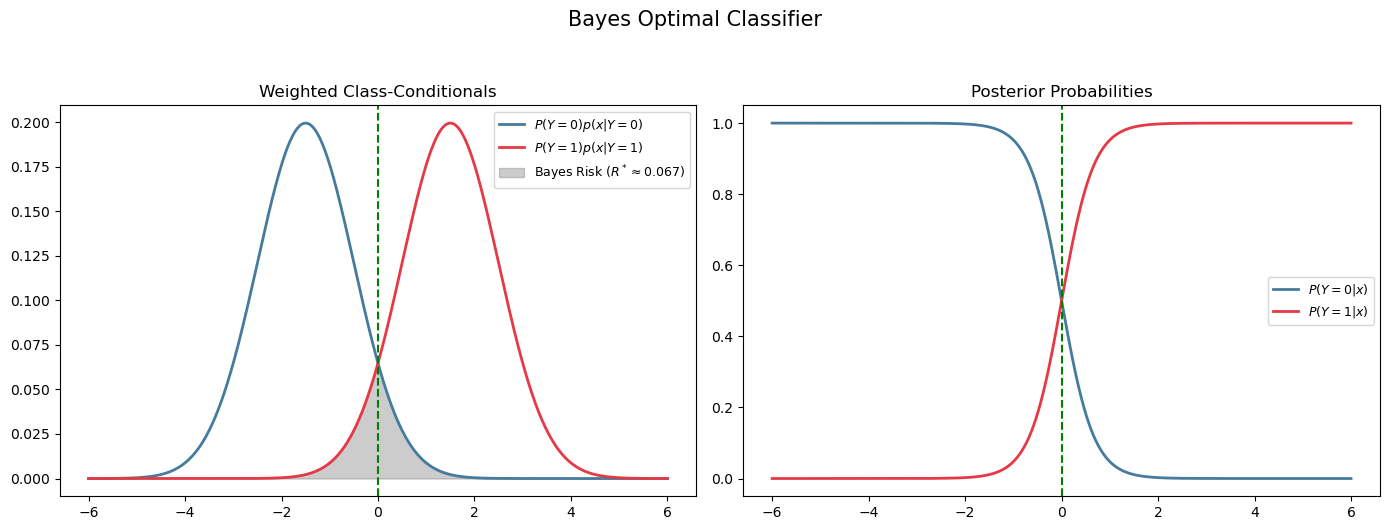

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 1. Setup
mu0, mu1, sigma = -1.5, 1.5, 1.0
x = np.linspace(-6, 6, 1000)
p0, p1 = norm.pdf(x, mu0, sigma), norm.pdf(x, mu1, sigma)
prior0 = prior1 = 0.5
p_x = prior0 * p0 + prior1 * p1
post0, post1 = (p0 * prior0) / p_x, (p1 * prior1) / p_x

# 2. Bayes Risk con fix per NumPy 2.0
try:
    bayes_risk = np.trapezoid(np.minimum(p0 * prior0, p1 * prior1), x)
except AttributeError:
    bayes_risk = np.trapz(np.minimum(p0 * prior0, p1 * prior1), x)

decision_boundary = (mu0 + mu1) / 2

# 3. Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafico a sinistra (Il fix è qui nella label)
ax = axes[0]
ax.plot(x, p0 * prior0, '#457B9D', lw=2, label='$P(Y=0)p(x|Y=0)$')
ax.plot(x, p1 * prior1, '#E63946', lw=2, label='$P(Y=1)p(x|Y=1)$')
ax.fill_between(x, np.minimum(p0 * prior0, p1 * prior1), color='gray', alpha=0.4, 
                label=fr'Bayes Risk ($R^* \approx {bayes_risk:.3f}$)') # <--- FIX
ax.axvline(decision_boundary, color='green', linestyle='--')
ax.set_title('Weighted Class-Conditionals')
ax.legend(fontsize=9)

# Grafico a destra
ax2 = axes[1]
ax2.plot(x, post0, '#457B9D', lw=2, label='$P(Y=0|x)$')
ax2.plot(x, post1, '#E63946', lw=2, label='$P(Y=1|x)$')
ax2.axvline(decision_boundary, color='green', linestyle='--')
ax2.set_title('Posterior Probabilities')
ax2.legend(fontsize=9)

plt.suptitle('Bayes Optimal Classifier', fontsize=15, y=1.05)
plt.tight_layout()
plt.show()

---
# 6. Excess Risk, Consistency & Universality

## 6.1 Excess Risk Decomposition

Given a learner $A$ that returns $h_S = A(S)$ from training data $S$, its **excess risk** measures how much worse it is than the Bayes optimal:

$$
\mathcal{E}(h_S) = R(h_S) - R^*
$$

We can decompose this into two meaningful components:

$$
\underbrace{R(h_S) - R^*}_{\text{Excess Risk}} = \underbrace{R(h_S) - \inf_{h \in \mathcal{H}} R(h)}_{\text{Estimation Error}} + \underbrace{\inf_{h \in \mathcal{H}} R(h) - R^*}_{\text{Approximation Error}}
$$

| Component | Cause | How to reduce |
|---|---|---|
| **Estimation error** | Finite sample — $h_S$ may not find the best $h \in \mathcal{H}$ | More data, better algorithm |
| **Approximation error** | $\mathcal{H}$ may not contain $h^*$ | Larger / richer $\mathcal{H}$ |

Note the tension: increasing $\mathcal{H}$ reduces approximation error but increases estimation error (harder to learn from finite data).

---

## 6.2 Consistency

A learning algorithm $A$ is **consistent** with respect to distribution $\mathcal{D}$ if:

$$R(h_S) \xrightarrow{m \to \infty} R^* \quad \text{in probability}$$

As the training set grows, the algorithm's risk converges to the irreducible Bayes risk. This is the minimal requirement for a learning algorithm to be called "good."

## 6.3 Universally Consistent

A stronger requirement: a learner is **universally consistent** if it is consistent for *every* distribution $\mathcal{D}$.

The $k$-Nearest Neighbors classifier (with $k \to \infty$, $k/m \to 0$) is a classical example of a universally consistent algorithm (Stone, 1977).

<>:18: SyntaxWarning: invalid escape sequence '\m'
<>:18: SyntaxWarning: invalid escape sequence '\m'
C:\Users\user\AppData\Local\Temp\ipykernel_3448\3554801390.py:18: SyntaxWarning: invalid escape sequence '\m'
  (0.45, r'$\inf_{h\in\mathcal{H}} R(h)$', '#3498DB', 'Best in class ($\mathcal{H}$)'),


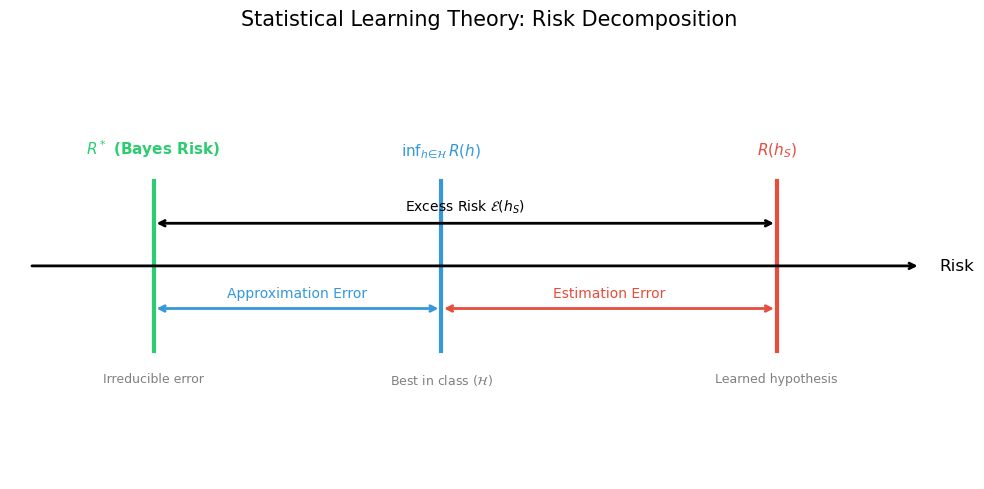

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Creazione della figura
fig, ax = plt.subplots(figsize=(10, 5))
ax.axis('off')

# 1. Asse del rischio (linea orizzontale)
ax.annotate('', xy=(0.95, 0.5), xytext=(0.02, 0.5),
            xycoords='axes fraction',
            arrowprops=dict(arrowstyle='->', color='black', lw=2))
ax.text(0.97, 0.5, 'Risk', ha='left', va='center', fontsize=12, transform=ax.transAxes)

# 2. Livelli di Rischio (Posizioni x, Label, Colore, Descrizione)
# Nota: xpos qui è inteso in coordinate 'axes fraction' (0 a 1)
levels = [
    (0.15, r'$R^*$ (Bayes Risk)', '#2ECC71', 'Irreducible error'),
    (0.45, r'$\inf_{h\in\mathcal{H}} R(h)$', '#3498DB', 'Best in class ($\mathcal{H}$)'),
    (0.80, r'$R(h_S)$', '#E74C3C', 'Learned hypothesis'),
]

for xpos, label, color, desc in levels:
    # CORREZIONE: rimosso transform=ax.transAxes da axvline
    ax.axvline(xpos, ymin=0.3, ymax=0.7, color=color, lw=3)
    
    # I testi hanno ancora bisogno del transform per essere posizionati correttamente
    ax.text(xpos, 0.75, label, ha='center', va='bottom', fontsize=11,
            color=color, transform=ax.transAxes, fontweight='bold')
    ax.text(xpos, 0.25, desc, ha='center', va='top', fontsize=9,
            color='gray', transform=ax.transAxes)

# 3. Funzione per disegnare le "parentesi" (frecce bidirezionali)
def draw_error_range(ax, x1, x2, y, label, color):
    ax.annotate('', xy=(x2, y), xytext=(x1, y),
                xycoords='axes fraction',
                arrowprops=dict(arrowstyle='<->', color=color, lw=2))
    ax.text((x1+x2)/2, y+0.02, label, ha='center', va='bottom', fontsize=10,
            color=color, transform=ax.transAxes)

# Disegniamo i vari tipi di errore
draw_error_range(ax, 0.15, 0.45, 0.40, 'Approximation Error', '#3498DB')
draw_error_range(ax, 0.45, 0.80, 0.40, 'Estimation Error', '#E74C3C')
draw_error_range(ax, 0.15, 0.80, 0.60, r'Excess Risk $\mathcal{E}(h_S)$', 'black')

# Titolo e visualizzazione
ax.set_title('Statistical Learning Theory: Risk Decomposition', fontsize=15, pad=20)
plt.tight_layout()
plt.show()

---
# 7. No Free Lunch Theorem

## 7.1 Statement

**Theorem (No Free Lunch — Wolpert & Macready, 1997):**
For any learning algorithm $A$, there exists a distribution $\mathcal{D}$ such that:

$$
R(h_S) \geq \frac{1}{2}
$$

with high probability over draws of any training set $S$ of any fixed size $m < |\mathcal{X}|/2$.

In other words: **no single algorithm is universally better than random guessing** across all possible distributions.

## 7.2 Interpretation

The NFL theorem formalizes a deep truth:

> *Every learning algorithm embeds assumptions about the world. These assumptions help on some distributions and hurt on others.*

- An algorithm that works brilliantly on smooth, structured distributions (e.g., neural networks on images) may perform no better than random on adversarial or pathological distributions
- There is no "master algorithm" that dominates everything
- **Inductive bias is not a weakness — it is a necessity**

## 7.3 Practical Implication

The NFL theorem does not say all algorithms are equally good in practice. It says that if we want to learn successfully, we must make assumptions — about smoothness, linearity, locality, or other structure — that match the problem at hand.

This is why domain knowledge matters: a good prior on the problem structure is what separates useful models from useless ones.

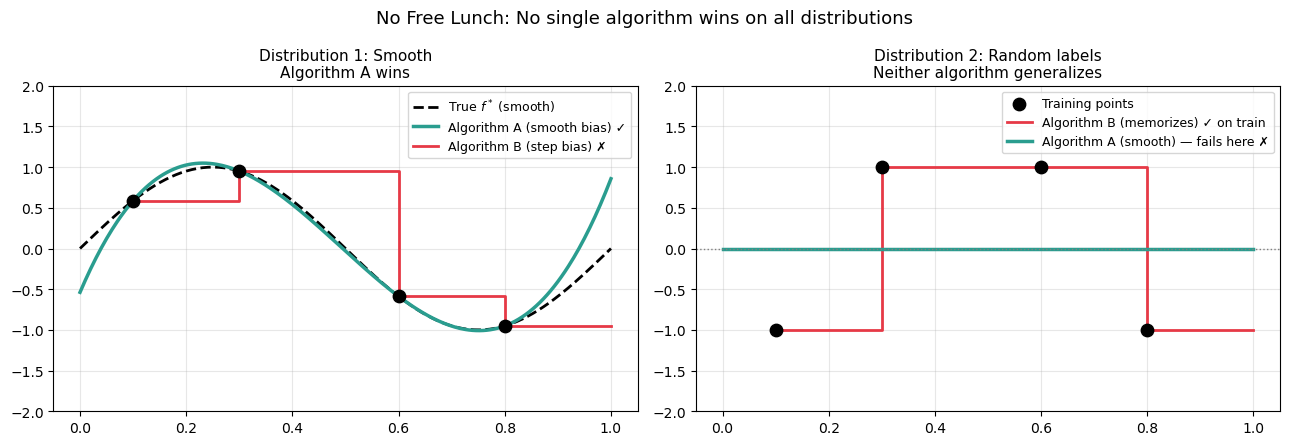

In [7]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# Two algorithms: one biased toward smooth functions, one toward step functions
x_train = np.array([0.1, 0.3, 0.6, 0.8])
x_plot  = np.linspace(0, 1, 300)

# Distribution 1: smooth sinusoid → algorithm A wins
y_smooth = np.sin(2*np.pi*x_train)
# Distribution 2: random labels → algorithm B (memorize) wins on train, fails on test
y_random = np.random.choice([-1, 1], size=len(x_train))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# --- Left: smooth distribution ---
ax = axes[0]
ax.plot(x_plot, np.sin(2*np.pi*x_plot), 'k--', lw=2, label='True $f^*$ (smooth)')
ax.scatter(x_train, y_smooth, s=80, zorder=5, color='black')
# Smooth interpolation ("right" algorithm here)
from numpy.polynomial import polynomial as P
coeff = np.polyfit(x_train, y_smooth, 3)
ax.plot(x_plot, np.polyval(coeff, x_plot), '#2A9D8F', lw=2.5, label='Algorithm A (smooth bias) ✓')
# Step interpolation ("wrong" algorithm here)
ax.step(np.append(x_train, 1), np.append(y_smooth, y_smooth[-1]),
        '#E63946', lw=2, where='post', label='Algorithm B (step bias) ✗')
ax.set_title('Distribution 1: Smooth\nAlgorithm A wins', fontsize=11)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3); ax.set_ylim(-2, 2)

# --- Right: adversarial / random ---
ax2 = axes[1]
ax2.scatter(x_train, y_random, s=80, zorder=5, color='black', label='Training points')
ax2.step(np.append(x_train, 1), np.append(y_random, y_random[-1]),
         '#E63946', lw=2, where='post', label='Algorithm B (memorizes) ✓ on train')
ax2.plot(x_plot, np.polyval(np.polyfit(x_train, y_random, 1), x_plot),
         '#2A9D8F', lw=2.5, label='Algorithm A (smooth) — fails here ✗')
ax2.axhline(0, color='gray', lw=1, linestyle=':')
ax2.set_title('Distribution 2: Random labels\nNeither algorithm generalizes', fontsize=11)
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3); ax2.set_ylim(-2, 2)

plt.suptitle('No Free Lunch: No single algorithm wins on all distributions', fontsize=13)
plt.tight_layout()
plt.show()

---
# 8. Estimation & Approximation Error — Bias-Variance Trade-off

## 8.1 Bias-Variance Decomposition

For regression with squared loss, the expected risk of any hypothesis $h_S$ (where the expectation is over the randomness in $S$) decomposes as:

$$
\mathbb{E}_S\left[R(h_S)\right] = \underbrace{\sigma^2}_{\text{Noise}} + \underbrace{\text{Bias}^2(h_S)}_{\text{Approximation}} + \underbrace{\text{Var}(h_S)}_{\text{Estimation}}
$$

where:
- **Noise** $\sigma^2 = R^*$ — irreducible, comes from $\mathcal{D}$ itself
- **Bias** $= \mathbb{E}_S[h_S(x)] - f^*(x)$ — systematic error from wrong assumptions ($\mathcal{H}$ too small)
- **Variance** $= \mathbb{E}_S[(h_S(x) - \mathbb{E}_S[h_S(x)])^2]$ — sensitivity to the training sample ($\mathcal{H}$ too large)

## 8.2 The Trade-off

| Model Complexity | Bias | Variance | Total Error |
|---|---|---|---|
| Too simple (small $\mathcal{H}$) | High | Low | High (underfitting) |
| Just right | Low | Low | Low |
| Too complex (large $\mathcal{H}$) | Low | High | High (overfitting) |

## 8.3 Connection to Excess Risk Decomposition

The bias-variance trade-off is the *statistical manifestation* of the estimation-approximation decomposition:

$$
\underbrace{\text{Approximation error}}_{ \approx \text{Bias}^2} + \underbrace{\text{Estimation error}}_{\approx \text{Variance}}
$$

> **Modern note:** In overparameterized models (deep learning), the classical bias-variance trade-off breaks down. Models with far more parameters than training points can still generalize — a phenomenon known as **double descent** (Belkin et al., 2019).

---
## Summary

| Concept | Key formula / idea | Why it matters |
|---|---|---|
| True Risk | $R(h) = \mathbb{E}_{\mathcal{D}}[\ell(h(x),y)]$ | What we truly want to minimize |
| Empirical Risk | $\hat{R}_S(h) = \frac{1}{m}\sum \ell(h(x_i),y_i)$ | The proxy we can compute |
| ERM | $h_S = \arg\min_{h \in \mathcal{H}} \hat{R}_S(h)$ | The core optimization principle |
| Hinge Loss | $\max(0, 1-y\hat{y})$ | SVM — sparse, convex |
| Log Loss | $\log(1+e^{-y\hat{y}})$ | Logistic reg — smooth, probabilistic |
| Bayes Risk | $R^* = \mathbb{E}_x[\min(P(y=0|x), P(y=1|x))]$ | Irreducible floor |
| Excess Risk | $R(h_S) - R^*$ = Approx. error + Estim. error | Decomposition of generalization gap |
| Consistency | $R(h_S) \to R^*$ as $m \to \infty$ | Minimal requirement for a good learner |
| No Free Lunch | No algorithm works for all distributions | Inductive bias is necessary |
| Bias-Variance | Bias² + Variance + Noise | Statistical view of the trade-off |

---

**➡️ Continue in Section 2 — PAC Learning:**
We now make these ideas precise: under what conditions does ERM provably generalize? How many samples do we need? This leads to **PAC Learning**, the **finite class case**, **VC dimension**, and **shattering**.